# # 기초통계 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 분석 데이타 : house_edu.csv

[분석 요건]
- 분석 주제 : 주택가격 예측 모형 생성 위한 기초 통계 분석
- 분석 단위 : 주택
- 종속 변수 : 주택가격 (price)
- 설명 변수 : 주택정보 (주택면적, 거실수, 층수, 건축기간 등)

[주요 실습 내용]
- 용어 학습 : 변수, 범주형변수 vs 연속형변수, 종속변수 vs 독립변수, 파생변수 등
- 기초 통계량 확인 : 대표값, 표준편차, 사분위수, 왜도, 첨도 등
- 데이타 변환 : Missing 처리, Outlier 처리, 데이터 Scaling, 분포 변환, One-Hot Encoding 등
- 상관 분석
- 회귀 분석


# 한글 폰트 설치

In [348]:
!sudo apt-get install -y fonts-nanum
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [349]:
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔고딕을 matplotlib 폰트 매니저에 '직접' 등록
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

**!! 메뉴에서 "런타임" → "세션 다시 시작"**

# 데이터 준비
- 주택 가격 예측 모델 생성용 공개 데이터셋
- 원본 : https://www.kaggle.com/datasets/harlfoxem/housesalesprediction
- 교육 목적으로 원본 데이터를 일부 변형 시킴
- 변수 설명
| 변수명 | 의미 | 비고 |
|--------|------|------|
| id | 주택 거래 고유 식별자 | |
| date | 주택 판매 날짜 | |
| price | 주택 판매 가격 | **종속변수(Target)** |
| bedrooms | 침실 개수 | |
| living_area | 거실(주거) 면적 | |
| lot_area | 토지 면적 | |
| floors | 층수 | |
| waterfront | 워터뷰 여부 (0=없음, 1=있음) | |
| grade | 건물 품질 및 디자인 등급 | |
| above_area | 지상 면적 | |
| basement_area | 지하실 면적 | |
| yr_built | 건축 연도 | |
| zipcode | 우편번호 | |

데이터 불러오기

In [350]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [351]:
pwd

'/content'

- 마운트한 주소 기준으로 데이터 불러와야함

In [352]:
import pandas as pd

# 구글 코랩 드라이브 마운트 후 정확한 경로 지정
file_path = '/content/drive/MyDrive/SKALA/2주차/house_edu.csv'

# 데이터 불러오기
df = pd.read_csv(file_path, encoding="cp949")
df.head()

,id,date,price,bedrooms,living_area,lot_area,floors,waterfront,grade,above_area,basement_area,yr_built,zipcode
0,1999700045,20140502T000000,313000,3.0,1340.0,7912,1.5,0.0,7등급,1340,0,1955.0,98133
1,5467900070,20140502T000000,342000,3.0,1930.0,11947,1.0,0.0,8등급,1930,0,1966.0,98042
2,4040800810,20140502T000000,420000,3.0,2000.0,8030,1.0,0.0,8등급,1000,1000,1963.0,98008
3,1860600135,20140502T000000,2380000,5.0,3650.0,9050,2.0,0.0,10등급,3370,280,1921.0,98119
4,6865200444,20140505T000000,531000,2.0,1270.0,1175,2.0,0.0,8등급,1110,160,2000.0,98103


데이터 조회하기

In [353]:
test_df = df.copy()

In [354]:
pip install ydata_profiling

In [355]:
import pandas as pd
import ydata_profiling
from ydata_profiling import ProfileReport

In [356]:
report = ProfileReport(df, title="Pandas Profiling Report", explorative=True)

In [357]:
# report

불필요 변수 제거

In [358]:
test_df = test_df.drop(columns=["id","zipcode"])

컬럼정보 확인


In [359]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1000 non-null   object 
 1   price          1000 non-null   int64  
 2   bedrooms       980 non-null    float64
 3   living_area    980 non-null    float64
 4   lot_area       1000 non-null   int64  
 5   floors         1000 non-null   float64
 6   waterfront     978 non-null    float64
 7   grade          995 non-null    object 
 8   above_area     1000 non-null   int64  
 9   basement_area  1000 non-null   int64  
 10  yr_built       980 non-null    float64
dtypes: float64(5), int64(4), object(2)
memory usage: 86.1+ KB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입 (int, float, object 등)
  - int : 연속형 (정수형)
  - float : 연속형 (실수형)
  - object : 보통 문자열 (범주형)
  - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
  - datetime : 날짜형

컬럼타입 변경

In [360]:
test_df["date"] = pd.to_datetime(test_df["date"])                   # 문자열 -> 날짜 type으로 변환
test_df["waterfront"] = test_df["waterfront"].astype("category")    # 실수형 -> 범주형으로 변환

컬럼타입 재확인

In [361]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           1000 non-null   datetime64[ns]
 1   price          1000 non-null   int64         
 2   bedrooms       980 non-null    float64       
 3   living_area    980 non-null    float64       
 4   lot_area       1000 non-null   int64         
 5   floors         1000 non-null   float64       
 6   waterfront     978 non-null    category      
 7   grade          995 non-null    object        
 8   above_area     1000 non-null   int64         
 9   basement_area  1000 non-null   int64         
 10  yr_built       980 non-null    float64       
dtypes: category(1), datetime64[ns](1), float64(4), int64(4), object(1)
memory usage: 79.4+ KB


### [Self-Practice]

- 실습 주제 : 생성형 AI 에게 데이타 정보를 제공하고 파생변수 추천 요청하기
- 실습 조건
  - 위 df.info() 결과에서 컬럼 정보를 Copy 해서 생성형 AI 에게 input 으로 제공  
- 실습 시나리오
   - 시나리오 1) 생성형 AI 에게 파생변수 추천 요청하기
   - 시나리오 2) 생성형 AI가 추천한 변수 의미 파악하기

In [362]:
test_df.columns

Index(['date', 'price', 'bedrooms', 'living_area', 'lot_area', 'floors',
       'waterfront', 'grade', 'above_area', 'basement_area', 'yr_built'],
      dtype='object')

In [363]:
# 파생 변수 형성

test_df["year"] = test_df["date"].dt.year
test_df["month"] = test_df["date"].dt.month
test_df["day"] = test_df["date"].dt.day

test_df["age"] = test_df["year"] - test_df["yr_built"]
test_df.head()


,date,price,bedrooms,living_area,lot_area,floors,waterfront,grade,above_area,basement_area,yr_built,year,month,day,age
0,2014-05-02,313000,3.0,1340.0,7912,1.5,0.0,7등급,1340,0,1955.0,2014,5,2,59.0
1,2014-05-02,342000,3.0,1930.0,11947,1.0,0.0,8등급,1930,0,1966.0,2014,5,2,48.0
2,2014-05-02,420000,3.0,2000.0,8030,1.0,0.0,8등급,1000,1000,1963.0,2014,5,2,51.0
3,2014-05-02,2380000,5.0,3650.0,9050,2.0,0.0,10등급,3370,280,1921.0,2014,5,2,93.0
4,2014-05-05,531000,2.0,1270.0,1175,2.0,0.0,8등급,1110,160,2000.0,2014,5,5,14.0


# 파생변수 생성

주택 나이 생성

In [364]:
df = test_df.copy()

In [365]:
df["house_age"] = df["date"].dt.year - df["yr_built"]   # 주택 판매 날짜 - 건축 연도

방 밀도 생성

In [366]:
import numpy as np

df["room_density"] = df["living_area"] / df["bedrooms"].replace(0, np.nan)   # 거실 면적 / 침실 개수

Date 컬럼 제거

In [367]:
df = df.drop(columns=["date"])  #주택 판매 날짜

In [368]:
df.head()

,price,bedrooms,living_area,lot_area,floors,waterfront,grade,above_area,basement_area,yr_built,year,month,day,age,house_age,room_density
0,313000,3.0,1340.0,7912,1.5,0.0,7등급,1340,0,1955.0,2014,5,2,59.0,59.0,446.666667
1,342000,3.0,1930.0,11947,1.0,0.0,8등급,1930,0,1966.0,2014,5,2,48.0,48.0,643.333333
2,420000,3.0,2000.0,8030,1.0,0.0,8등급,1000,1000,1963.0,2014,5,2,51.0,51.0,666.666667
3,2380000,5.0,3650.0,9050,2.0,0.0,10등급,3370,280,1921.0,2014,5,2,93.0,93.0,730.000000
4,531000,2.0,1270.0,1175,2.0,0.0,8등급,1110,160,2000.0,2014,5,5,14.0,14.0,635.000000


# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [369]:
import numpy as np

# 연속형 변수 분포 확인
df.select_dtypes(include=[np.number]).describe()

,price,bedrooms,living_area,lot_area,floors,above_area,basement_area,yr_built,year,month,day,age,house_age,room_density
count,1.000000e+03,980.000000,980.000000,1000.000000,1000.000000,1000.000000,1000.000000,980.000000,1000.000000,1000.000000,1000.000000,980.000000,980.000000,959.000000
mean,5.363811e+05,3.420408,2031.883673,14699.748000,1.446500,1749.093000,299.143000,1968.931633,2014.304000,6.637000,15.211000,45.373469,45.373469,607.362208
std,4.431954e+05,1.455079,894.292297,28961.536216,0.517354,790.610998,448.754794,28.257144,0.460213,3.169744,8.403041,28.266052,28.266052,225.610731
min,8.000000e+04,0.000000,-100.000000,649.000000,1.000000,380.000000,0.000000,1900.000000,2014.000000,1.000000,1.000000,0.000000,0.000000,-33.333333
25%,3.094500e+05,3.000000,1400.000000,5428.500000,1.000000,1190.000000,0.000000,1952.000000,2014.000000,4.000000,8.000000,22.000000,22.000000,458.750000
50%,4.350000e+05,3.000000,1900.000000,8038.000000,1.000000,1535.000000,0.000000,1974.000000,2014.000000,7.000000,15.000000,40.000000,40.000000,560.000000
75%,6.336938e+05,4.000000,2462.500000,11489.250000,2.000000,2132.500000,580.000000,1992.000000,2015.000000,9.000000,22.000000,62.000000,62.000000,700.000000
max,5.900000e+06,20.000000,6070.000000,315374.000000,3.500000,6070.000000,2060.000000,2015.000000,2015.000000,12.000000,31.000000,115.000000,115.000000,1975.000000


연속형 변수 분포 그래프 확인
 - 히스토그램 (Histogram) 차트 : 퍼짐, 쏠림, 정규분포 확인

연속형 변수: ['price', 'bedrooms', 'living_area', 'lot_area', 'floors', 'above_area', 'basement_area', 'yr_built', 'year', 'month', 'day', 'age', 'house_age', 'room_density']


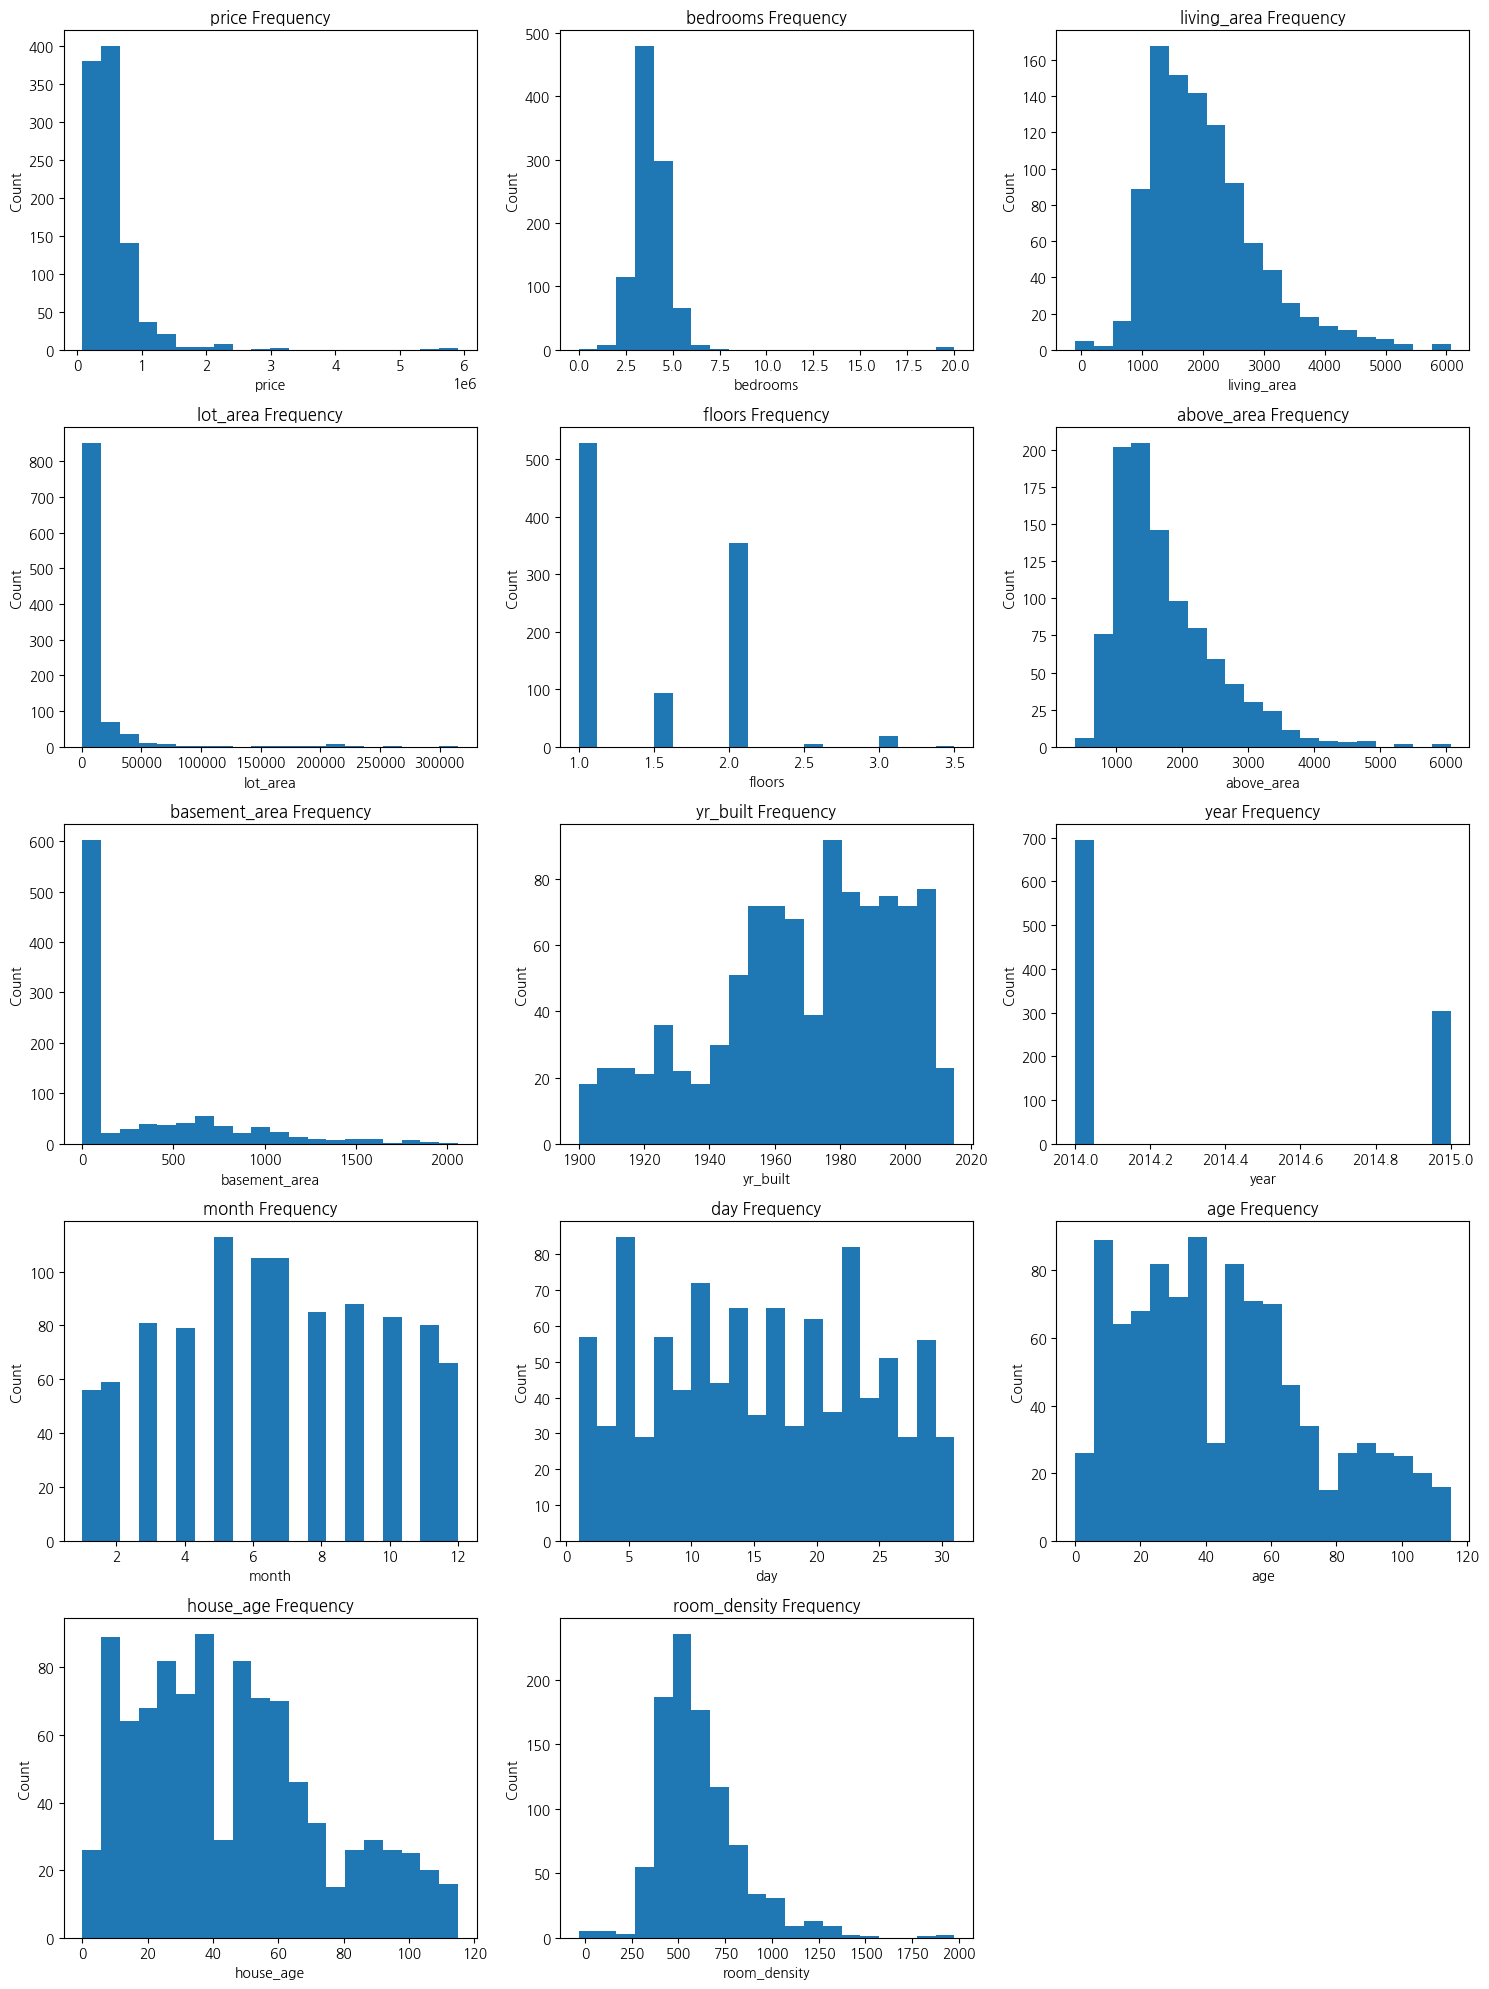

In [370]:
import numpy as np

# 연속형 변수 자동 추출
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("연속형 변수:", num_cols)

# 빈도 분포 히스토그램 (Frequency Histogram)
import matplotlib.pyplot as plt

n = len(num_cols)
cols = 3     # 한 행에 그래프 갯수
rows = (n // cols) + (n % cols > 0)

plt.figure(figsize=(cols*5, rows*4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"{col} Frequency")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

 - 박스 플롯(Box Plot) : 사분위수 범위 (IQR), 이상치 후보 확인

연속형 변수: ['price', 'bedrooms', 'living_area', 'lot_area', 'floors', 'above_area', 'basement_area', 'yr_built', 'year', 'month', 'day', 'age', 'house_age', 'room_density']


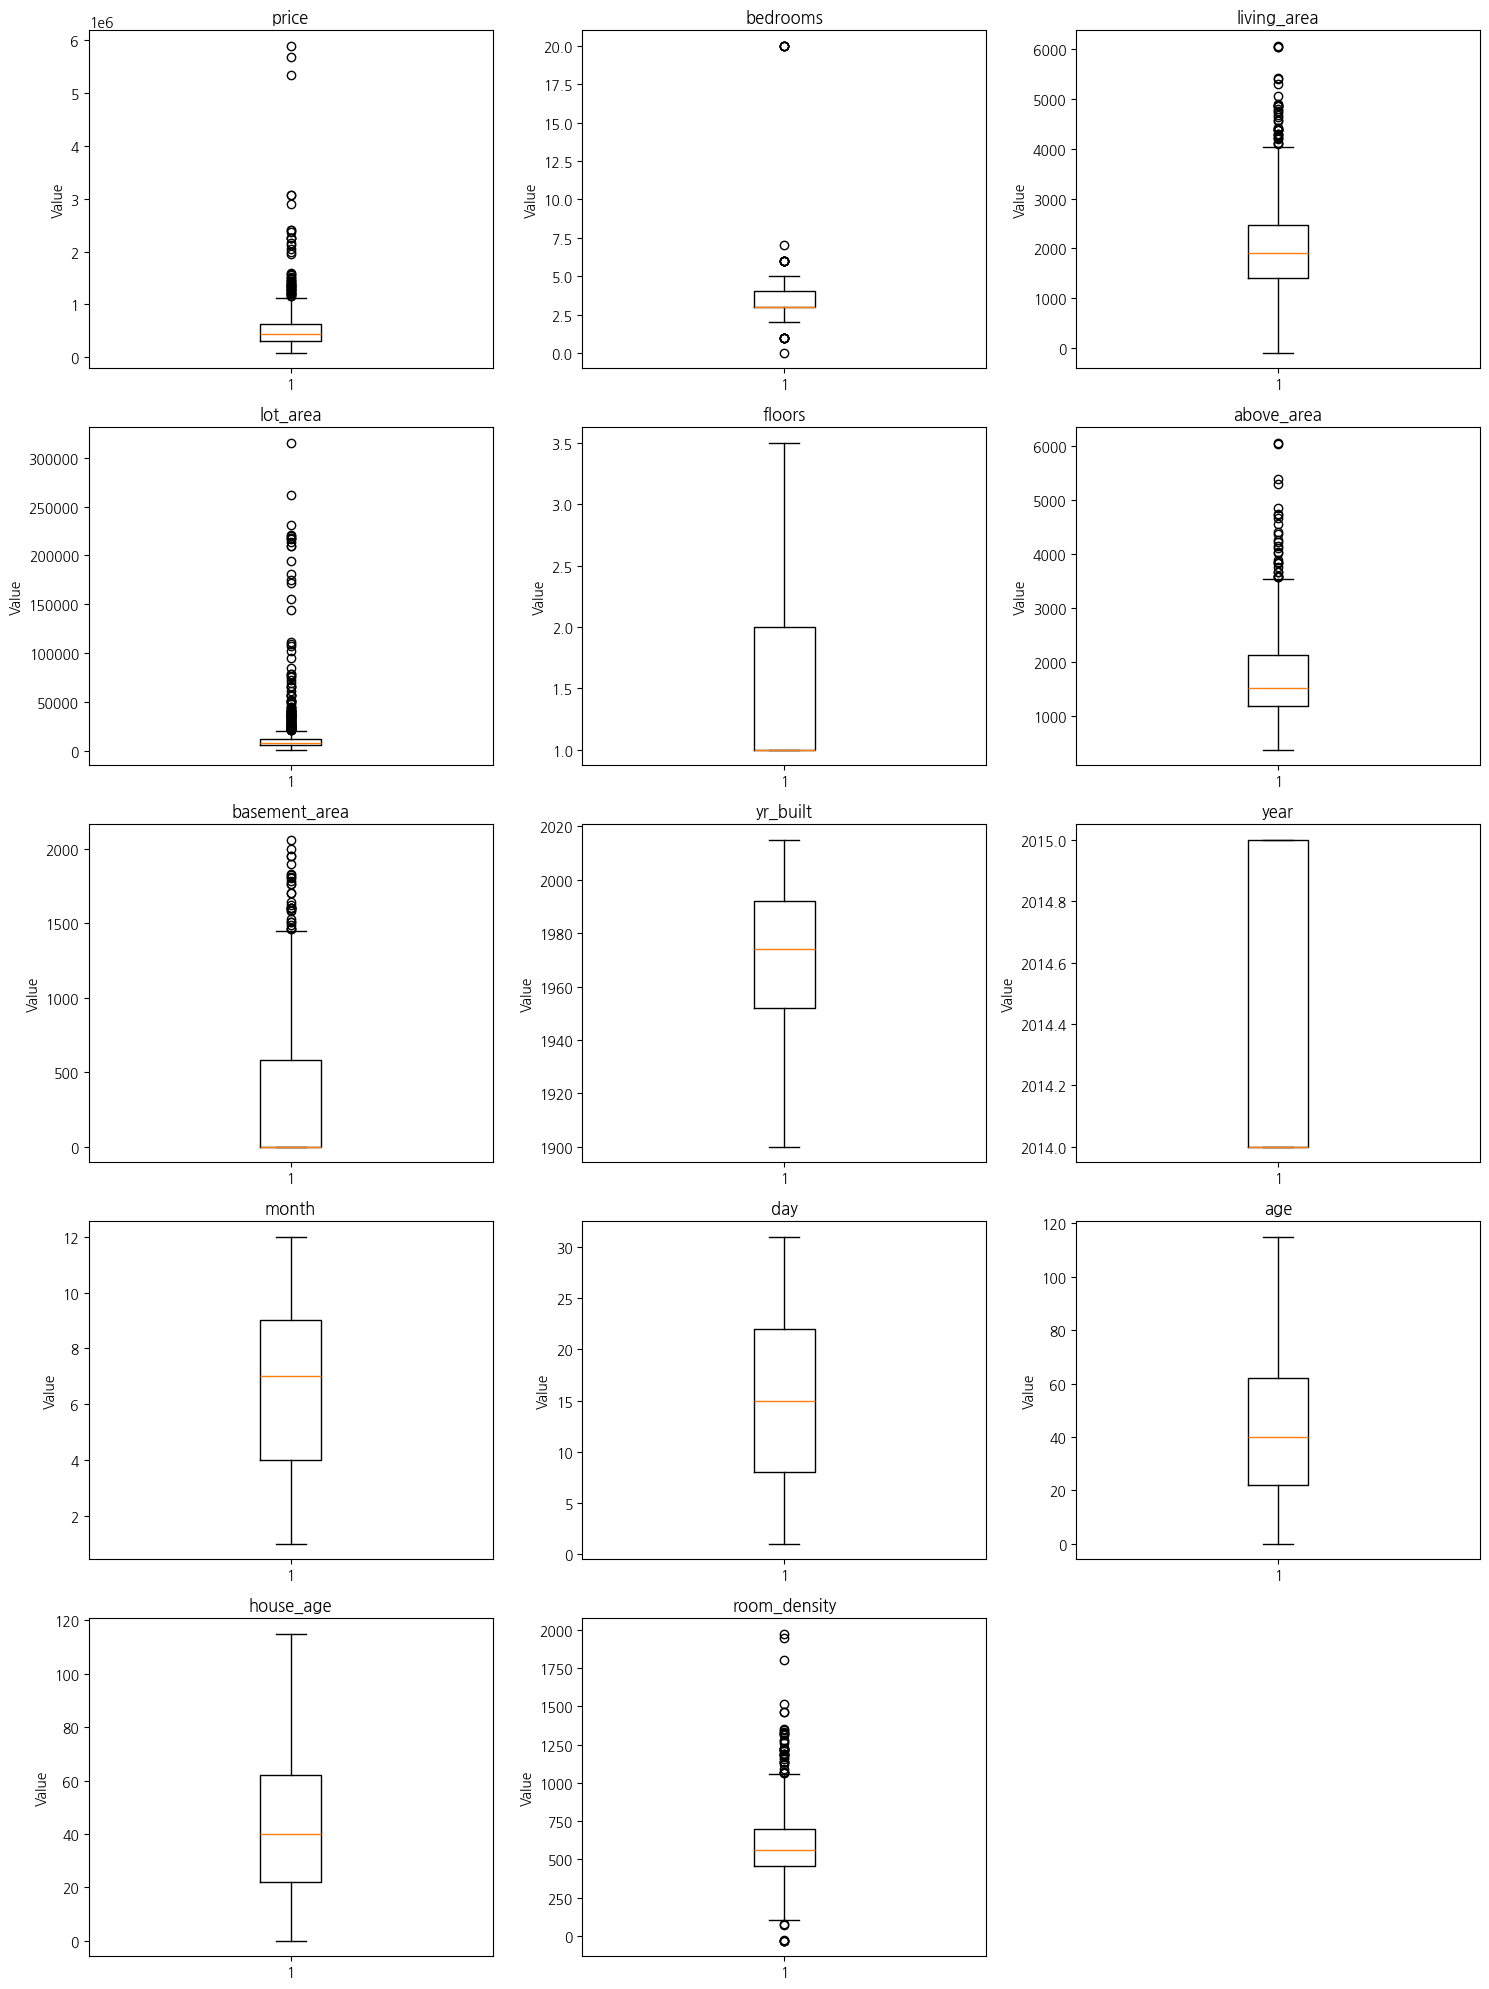

In [371]:
import numpy as np

# 연속형 변수 자동 추출
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("연속형 변수:", num_cols)

# 박스 플롯(Box Plot)
cols = 3    # 한 행에 그래프 갯수
rows = (len(num_cols) // cols) + (len(num_cols) % cols > 0)

plt.figure(figsize=(cols*5, rows*4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.ylabel("Value")

plt.tight_layout()
plt.show()


### 왜도, 첨도

In [372]:
import numpy as np

# 연속형 변수 자동 추출
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("연속형 변수:", num_cols)

# 왜도 & 첨도 계산
skew_kurt = pd.DataFrame({
    "Skewness": df[num_cols].skew(),     # 왜도 (>0: 오른쪽으로 치우침, <0: 왼쪽으로 치우팀, 0=좌우 대칭)
    "Kurtosis": df[num_cols].kurt()      # 첨도 (>0: 뾰족, <0: 납작, 0=정규분포)
})

print(skew_kurt.sort_values(by="Skewness", ascending=False))

연속형 변수: ['price', 'bedrooms', 'living_area', 'lot_area', 'floors', 'above_area', 'basement_area', 'yr_built', 'year', 'month', 'day', 'age', 'house_age', 'room_density']
               Skewness   Kurtosis
bedrooms       7.570608  84.023873
lot_area       6.084037  42.041201
price          5.943756  56.559608
above_area     1.479241   3.129788
basement_area  1.473614   1.463203
room_density   1.390172   4.460976
living_area    1.155386   1.994407
year           0.853487  -1.274112
floors         0.687712  -0.436184
age            0.543008  -0.541922
house_age      0.543008  -0.541922
day            0.051844  -1.160722
month         -0.013184  -1.015033
yr_built      -0.544298  -0.542915


범주형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상여부 확인
 - Missing 건수 확인
 - 데이터 밀집도 확인
 - 범주 갯수 확인

In [373]:
# 범주형 변수 자동 추출
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 범주 건수 & 비율 계산
for col in cat_cols:
    print(f"\n[{col}]")
    dist = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({
        "count": dist,
        "ratio_%": ratio.round(2)
    })
    print(result)


[waterfront]
            count  ratio_%
waterfront                
 0.0          970     97.0
NaN            22      2.2
 1.0            8      0.8

[grade]
       count  ratio_%
grade                
7등급      442     44.2
8등급      267     26.7
9등급      111     11.1
6등급       92      9.2
10등급      46      4.6
11등급      18      1.8
5등급       12      1.2
NaN        5      0.5
12등급       5      0.5
4등급        2      0.2


범주형 변수 분포 그래프 확인
 - 히스토그램 (Histogram) 차트

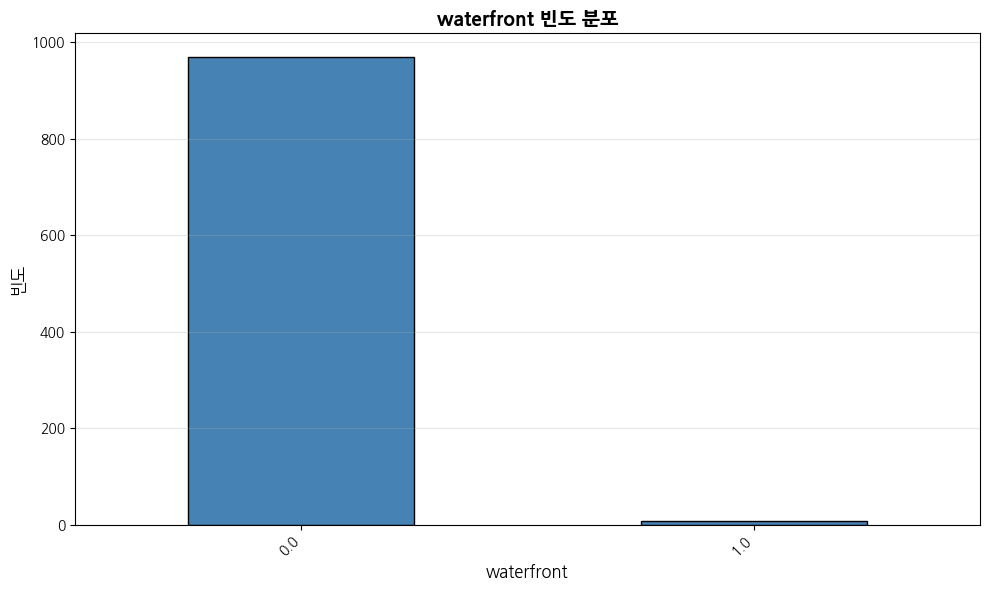

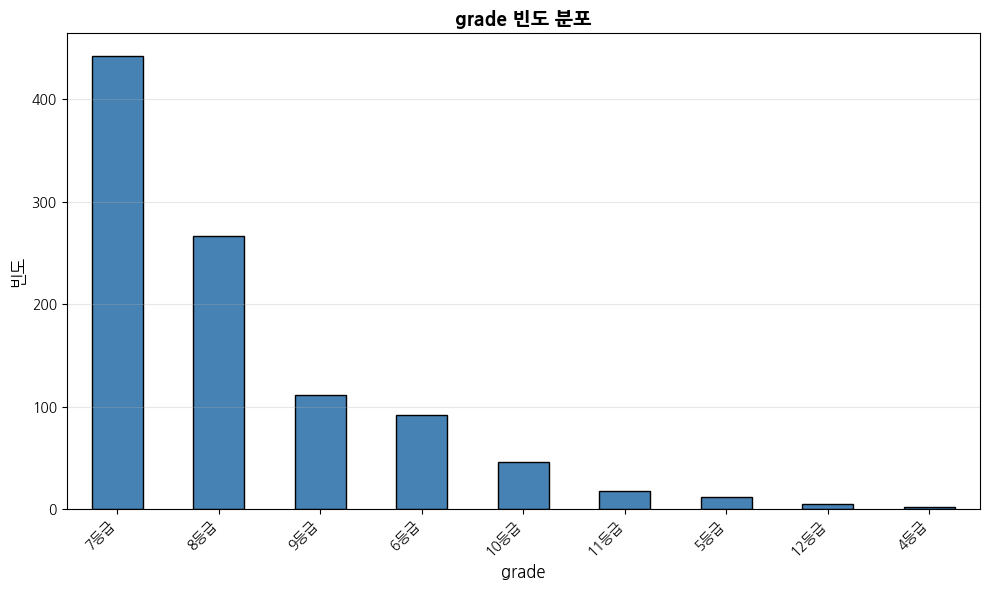

In [374]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 범주형 변수 찾기
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 시각화
for col in cat_cols:
    plt.figure(figsize=(10, 6))

    # 막대 그래프
    df[col].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')

    plt.title(f'{col} 빈도 분포', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('빈도', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

- 변수가 너무 많음 통합하자!

목표변수 vs 설명변수 관계 확인
- 연속형 설명변수 산점도(Scatter Plot)

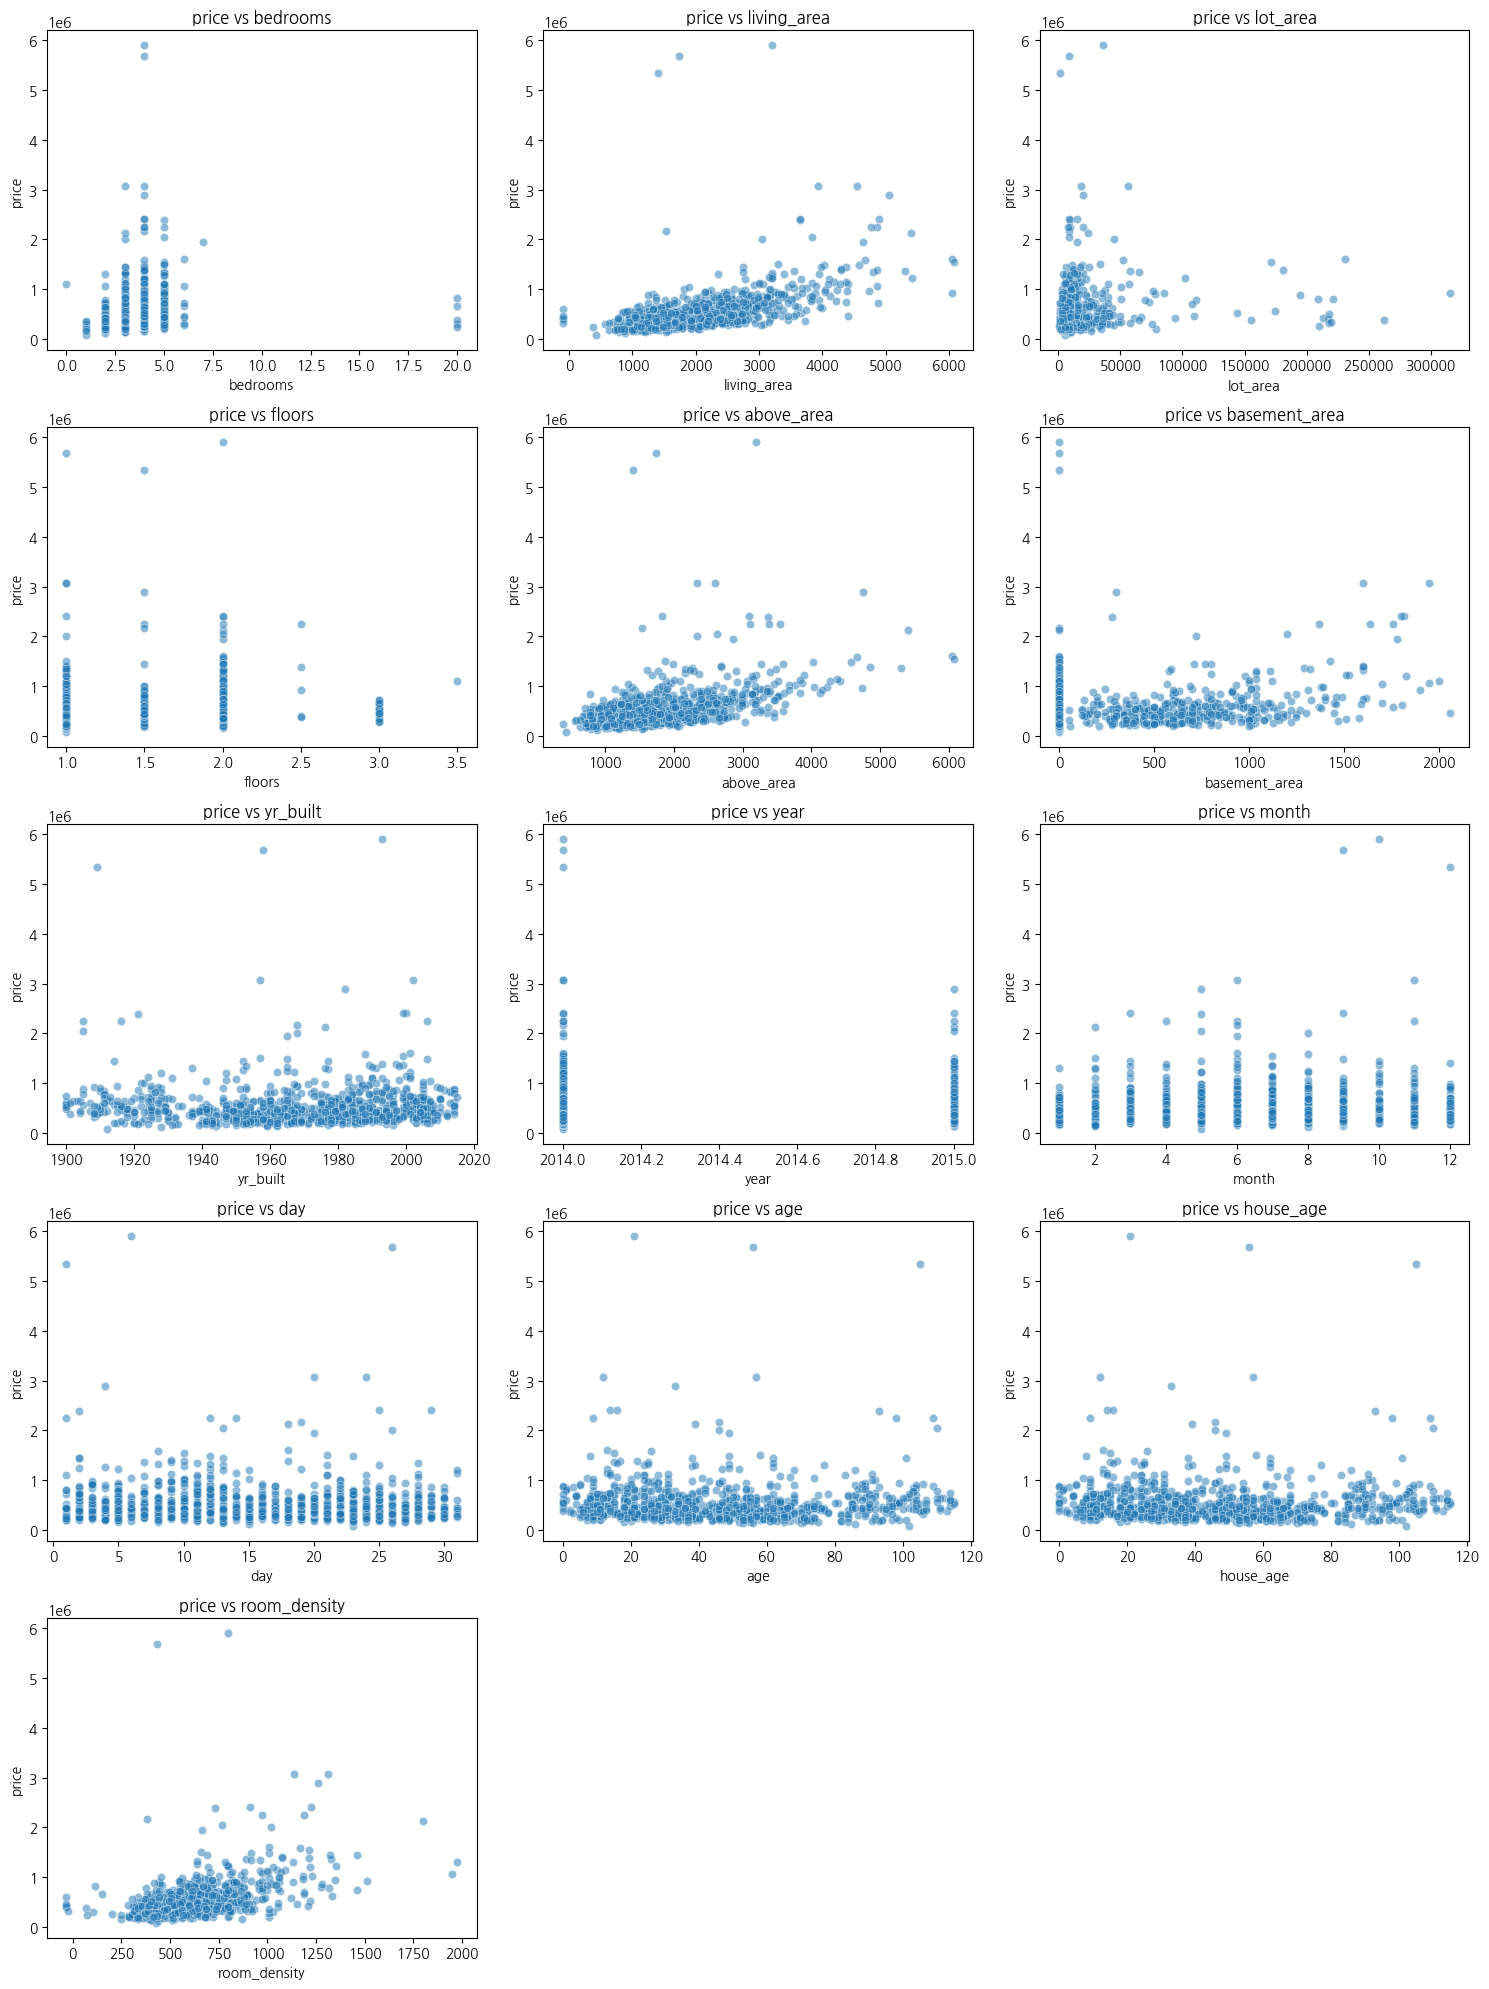

In [375]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 연속형 변수 추출
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# 목표변수(price) 제외
feature_cols = [col for col in num_cols if col != "price"]

# Scatter Plot
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(feature_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.scatterplot(data=df, x=col, y="price", alpha=0.5)
    plt.title(f"price vs {col}")

plt.tight_layout()
plt.show()

목표변수 vs 설명변수 관계 확인
- 범주형 설명변수 박스 플롯(Box Plot)

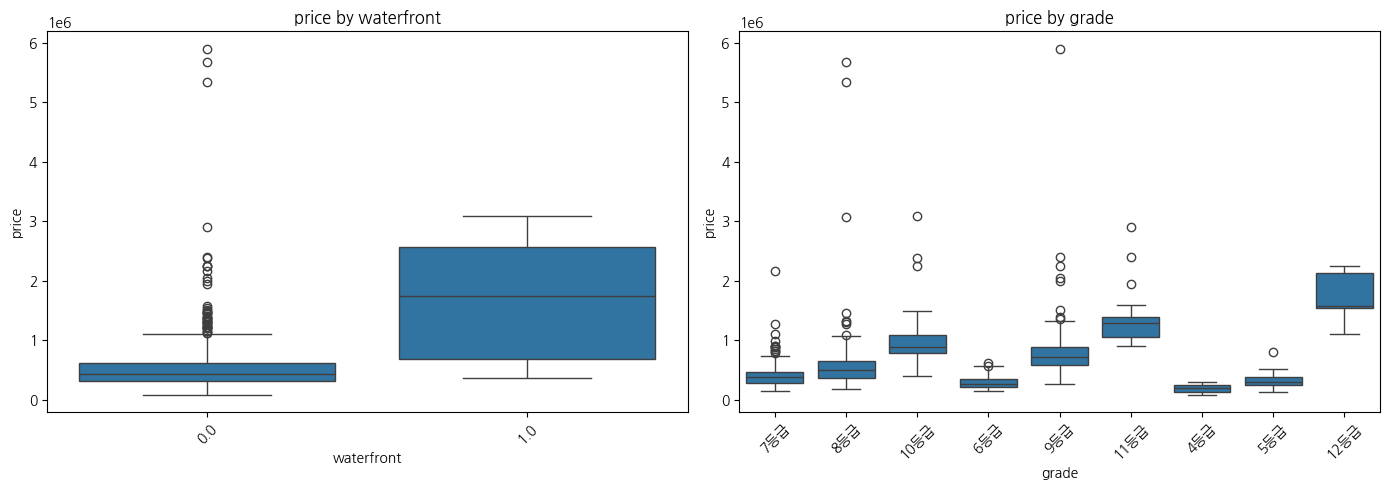

In [376]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 범주형 변수 추출
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

# Scatter Plot
n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

plt.figure(figsize=(14, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(
        data=df,
        x=col,
        y="price"
    )

    plt.title(f"price by {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### [Self-Practice]

- 실습 주제 : 파생변수를 신규로 추가해서 EDA 분석 재현하기
- 실습 조건
  - 파생 변수 1: 주택의 지하실 유무를 나타내는 범주형 변수 has_basement를 생성 (basement_area가 0보다 크면 1, 0이면 0)  
  - 파생 변수 2: 토지 면적 대비 건물 밀도를 나타내는 연속형 변수 living_lot_ratio 를 생성 (living_area / lot_area)
- 실습 시나리오
   - 시나리오 1) 위 조건으로 파생변수 2개를 만드는 코드 생성
   - 시나리오 2) 파생변수 2개가 포함된 df 데이타셋을 동일한 방식으로 EDA 수행
   - 시나리오 3) EDA 분석 결과 해석하기 (추가된 파생변수 중심으로)

In [377]:
## 시나리오 1)

# 1. 파생변수 1: 지하실 유무 (basement_area > 0 이면 1, 아니면 0)
df["has_basement"] = np.where(df["basement_area"] > 0, 1, 0)
df["has_basement"] = df["has_basement"].astype("category") # 범주형 변수로 변환

# 2. 파생변수 2: 토지 면적 대비 건물 밀도 (living_area / lot_area)
# lot_area가 0인 경우 발생할 오류 예방을 위해 replace 적용
df["living_lot_ratio"] = df["living_area"] / df["lot_area"].replace(0, np.nan)

# 생성 결과 확인
print(df[["basement_area", "has_basement", "living_area", "lot_area", "living_lot_ratio"]].head())

   basement_area has_basement  living_area  lot_area  living_lot_ratio
0              0            0       1340.0      7912          0.169363
1              0            0       1930.0     11947          0.161547
2           1000            1       2000.0      8030          0.249066
3            280            1       3650.0      9050          0.403315
4            160            1       1270.0      1175          1.080851


=== [has_basement] 빈도 분포 ===
has_basement
0    60.0
1    40.0
Name: proportion, dtype: float64

=== [living_lot_ratio] 기초 통계량 ===
count    980.000000
mean       0.283765
std        0.220430
min       -0.021277
25%        0.146667
50%        0.230782
75%        0.358842
max        1.742882
Name: living_lot_ratio, dtype: float64


/tmp/ipykernel_3560/2605944610.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="has_basement", y="price", ax=axes[0], palette="Set2")


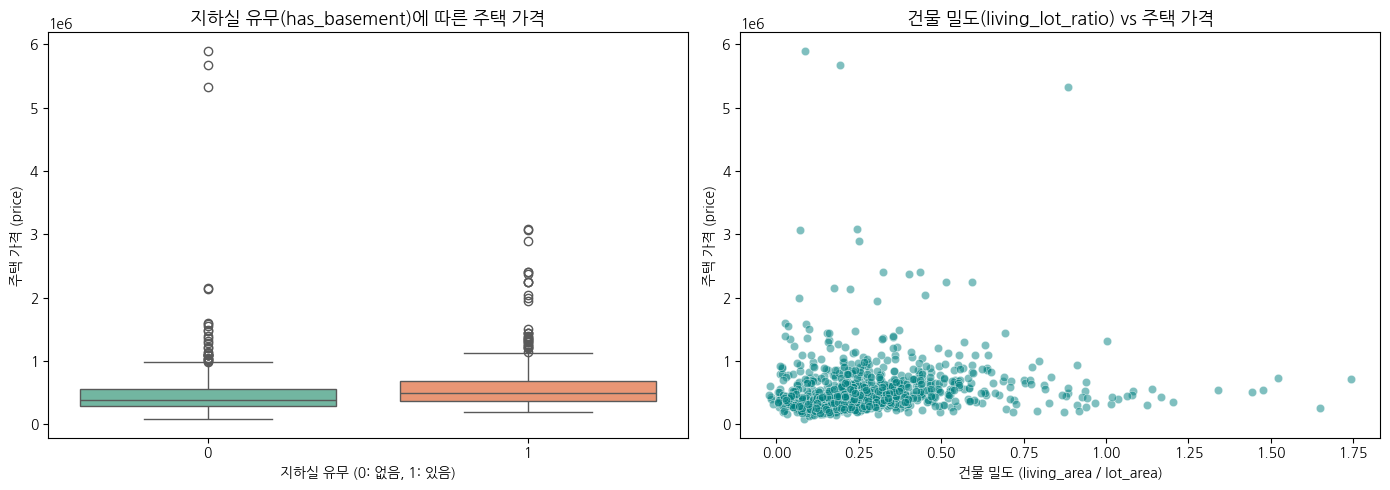

In [378]:
## 시나리오 2)

# 한글 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# ----------------------------------------------------
# 1. 신규 변수 기본 분포 확인
# ----------------------------------------------------
print("=== [has_basement] 빈도 분포 ===")
print(df["has_basement"].value_counts(normalize=True, dropna=False) * 100)

print("\n=== [living_lot_ratio] 기초 통계량 ===")
print(df["living_lot_ratio"].describe())

# ----------------------------------------------------
# 2. 목표변수(price)와의 관계 시각화
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# [그래프 1] has_basement vs price (Box Plot)
sns.boxplot(data=df, x="has_basement", y="price", ax=axes[0], palette="Set2")
axes[0].set_title("지하실 유무(has_basement)에 따른 주택 가격", fontsize=13)
axes[0].set_xlabel("지하실 유무 (0: 없음, 1: 있음)")
axes[0].set_ylabel("주택 가격 (price)")

# [그래프 2] living_lot_ratio vs price (Scatter Plot)
sns.scatterplot(data=df, x="living_lot_ratio", y="price", alpha=0.5, ax=axes[1], color="teal")
axes[1].set_title("건물 밀도(living_lot_ratio) vs 주택 가격", fontsize=13)
axes[1].set_xlabel("건물 밀도 (living_area / lot_area)")
axes[1].set_ylabel("주택 가격 (price)")

plt.tight_layout()
plt.show()

- 대지 면적(lot_area)이 극단적으로 넓은 시외 외곽 지역의 집과, 토지 활용도가 높은 도심 지역 주택의 차이를 잘 반영해 줍니다. 다만 분포의 왜도(Skewness)가 크기 때문에 추후 Log 변환이나 이상치 Capping 처리를 거쳐 모델에 입력하는 것이 적합합니다.

# 데이터 전처리
비정상 데이터 처리

In [379]:
import numpy as np

# living_area < 0  → Missing
df.loc[df["living_area"] < 0, "living_area"] = np.nan

# Data Partition
 - 목적 : 모델이 학습에 사용하지 않은 새로운 데이터에서도 잘 동작하는지 검증하기 위함
 - Train  : Test 비율 (7 : 3)
- Train Set : 모델 학습용, Test Set : 모델 평가용
- 데이타 변환시 변환 통계량은 Train 데이터에서 계산하고, Test 데이터에는 그 기준을 적용해야 함 (Data Leakage 문제)

데이타 분할

In [380]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df,
    test_size=0.3,     # test 30%
    random_state=42,   # 재현성
    shuffle=True       # 섞어서 분리
)

원본 데이타 복제

In [381]:
df_train_raw = df_train.copy()
df_test_raw  = df_test.copy()

# Missing 처리
Missing 데이터 확인

In [382]:
df_train.isnull().sum()

,0
price,0
bedrooms,13
living_area,18
lot_area,0
floors,0
waterfront,12
grade,4
above_area,0
basement_area,0
yr_built,13


Missing 데이터 변환
- 연속형 변수 대체 : median

In [383]:
import numpy as np

# 연속형 변수만 선택
num_cols = df_train.select_dtypes(include=[np.number]).columns

# train 기준 중앙값 계산
median_values = df_train[num_cols].median()

# train, test 모두 중앙값으로 결측치 대체
df_train[num_cols] = df_train[num_cols].fillna(median_values)
df_test[num_cols]  = df_test[num_cols].fillna(median_values)

 - 범주형 변수 대체 : New class ('Unknown')

In [384]:
# 범주형 변수만 선택
cat_cols = df_train.select_dtypes(include=['object', 'category']).columns

# 신규 범주 (Unknown) 로 대체
for col in cat_cols:
    # train
    if df_train[col].dtype.name == 'category':
        df_train[col] = df_train[col].cat.add_categories('Unknown')
    df_train[col] = df_train[col].fillna('Unknown')

    # test
    if df_test[col].dtype.name == 'category':
        df_test[col] = df_test[col].cat.add_categories('Unknown')
    df_test[col] = df_test[col].fillna('Unknown')

Missing 데이터 재확인

In [385]:
df_train.isnull().sum()

,0
price,0
bedrooms,0
living_area,0
lot_area,0
floors,0
waterfront,0
grade,0
above_area,0
basement_area,0
yr_built,0


# Outlier 처리
 - 이상치 탐지 방법 : Z-score 기반 탐지 (|Z| > 3)
 - 이상치 대체 방법 : Z-score 경계값으로 대체
 - 이상치 탐지 대상 변수 : 연속형 설명변수 *종속변수가 이상치로 의심되는 경우 처리 -> 모델 안정성을 위해 분석 제외

In [386]:
import numpy as np

# 연속형 변수 추출
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

# 목표변수 제외
num_cols.remove("price")

# Z-score 기반 이상치 처리
for col in num_cols:

    # Train 기준 평균, 표준편차
    mean = df_train[col].mean()
    std = df_train[col].std()

    # |Z| > 3 경계값
    lower = mean - 3 * std
    upper = mean + 3 * std

    # Train 데이터 이상치 건수
    train_outlier_cnt = ((df_train[col] < lower) | (df_train[col] > upper)).sum()

    # Test 데이터 이상치 건수
    test_outlier_cnt = ((df_test[col] < lower) | (df_test[col] > upper)).sum()

    print(
        f"{col:20s} "
        f"Train:{train_outlier_cnt:3d}건 "
        f"Test:{test_outlier_cnt:3d}건"
    )

    # Train 데이터 Capping
    df_train[col] = np.clip(df_train[col], lower, upper)

    # Test 데이터도 동일 기준 적용
    df_test[col] = np.clip(df_test[col], lower, upper)

bedrooms             Train:  3건 Test:  2건
living_area          Train: 12건 Test:  3건
lot_area             Train: 12건 Test: 10건
floors               Train: 12건 Test:  7건
above_area           Train:  9건 Test:  5건
basement_area        Train:  9건 Test:  6건
yr_built             Train:  0건 Test:  0건
year                 Train:  0건 Test:  0건
month                Train:  0건 Test:  0건
day                  Train:  0건 Test:  0건
age                  Train:  0건 Test:  0건
house_age            Train:  0건 Test:  0건
room_density         Train: 10건 Test:  5건
living_lot_ratio     Train: 15건 Test: 10건


### [Self-Practice]

- 실습 주제 : 이상치 처리 방법 비교해 보기
- 실습 시나리오
   - 시나리오) Z-score 방법 대신 IQR 방법 적용 후 Train 데이타와 Test 데이타 이상치 건수 상호 비교하기

In [387]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if "price" in num_cols:
    num_cols.remove("price")
print("이상치 탐지")

iqr_summary = []

for col in num_cols:
    # 1. Train 데이터 기준으로 Q1, Q3 및 IQR 계산 (Data Leakage 방지)
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1

    # 2. IQR 경계값 설정 (Lower & Upper Bound)
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    # 3. Train / Test 데이터 이상치 건수 집계
    train_outlier_cnt = ((df_train[col] < lower) | (df_train[col] > upper)).sum()
    test_outlier_cnt = ((df_test[col] < lower) | (df_test[col] > upper)).sum()

    iqr_summary.append({
        "Variable": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "Lower Bound": round(lower, 2),
        "Upper Bound": round(upper, 2),
        "Train Outliers": train_outlier_cnt,
        "Test Outliers": test_outlier_cnt
    })

    print(f"{col:20s} | Lower: {lower:10.2f} | Upper: {upper:10.2f} | Train: {train_outlier_cnt:4d}건 | Test: {test_outlier_cnt:4d}건")

    # 4. 이상치 대체 (Capping) - Train 기준 경계값으로 동일 적용
    df_train[col] = np.clip(df_train[col], lower, upper)
    df_test[col] = np.clip(df_test[col], lower, upper)

# 결과를 DataFrame 형태로 요약 보기
df_iqr_summary = pd.DataFrame(iqr_summary)

이상치 탐지
bedrooms             | Lower:       1.50 | Upper:       5.50 | Train:   15건 | Test:    7건
living_area          | Lower:     -98.75 | Upper:    3951.25 | Train:   28건 | Test:   12건
lot_area             | Lower:   -3158.12 | Upper:   20228.88 | Train:   80건 | Test:   37건
floors               | Lower:      -0.50 | Upper:       3.50 | Train:    0건 | Test:    0건
above_area           | Lower:    -195.00 | Upper:    3525.00 | Train:   21건 | Test:    9건
basement_area        | Lower:    -886.50 | Upper:    1477.50 | Train:   19건 | Test:    8건
yr_built             | Lower:    1895.38 | Upper:    2048.38 | Train:    0건 | Test:    0건
year                 | Lower:    2012.50 | Upper:    2016.50 | Train:    0건 | Test:    0건
month                | Lower:      -3.50 | Upper:      16.50 | Train:    0건 | Test:    0건
day                  | Lower:     -13.38 | Upper:      43.62 | Train:    0건 | Test:    0건
age                  | Lower:     -33.00 | Upper:     119.00 | Train:    0건 | Test:    0건
hou

/tmp/ipykernel_3560/2920103508.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="has_basement", y="price", ax=axes[0], palette="Set2")


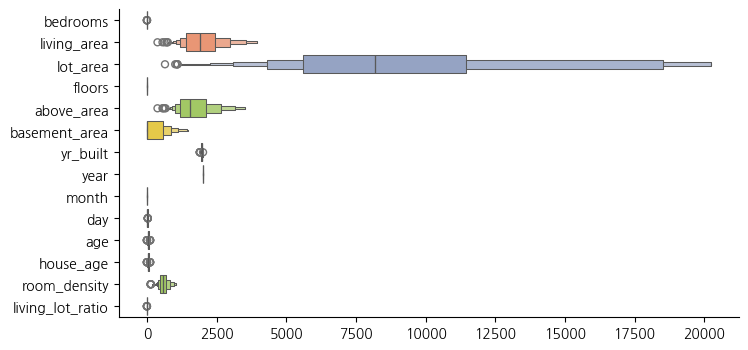

In [388]:
# iqr boxplot 시각화
sns.boxplot(data=df, x="has_basement", y="price", ax=axes[0], palette="Set2")
sns.boxenplot(data=df_train[num_cols], orient="h", palette="Set2")
sns.despine()

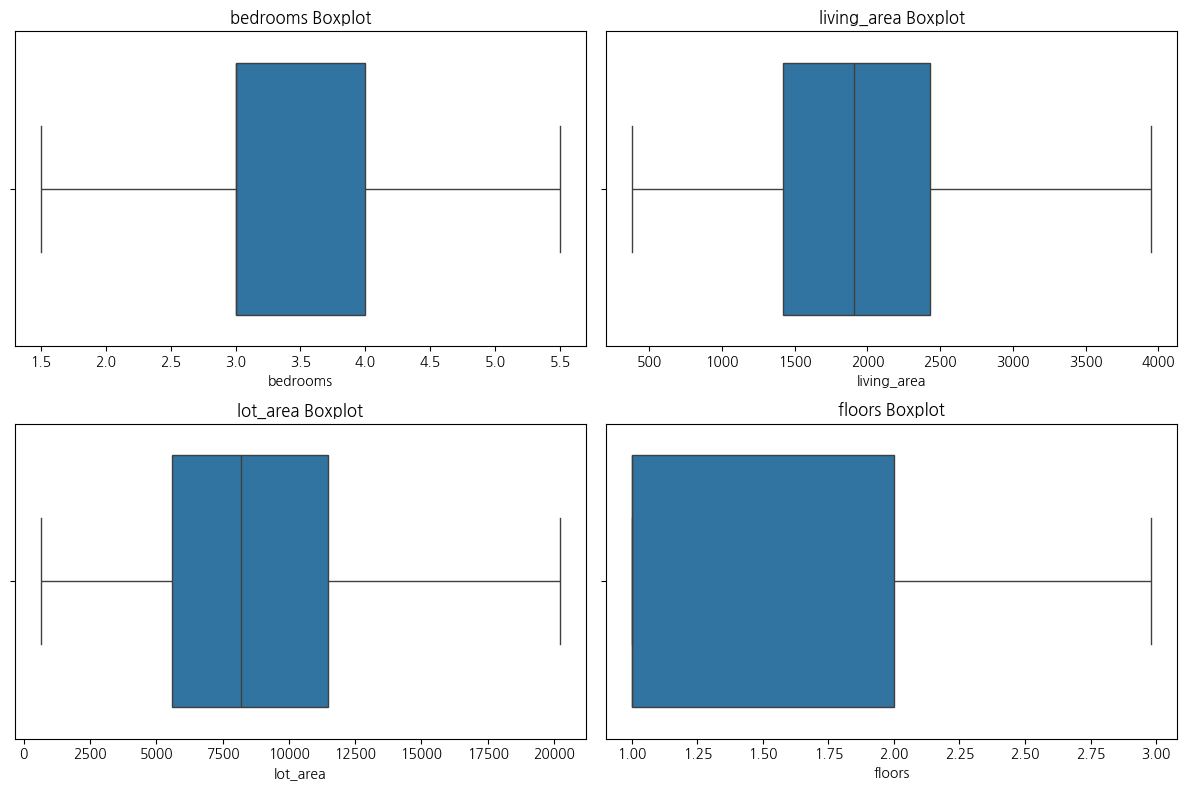

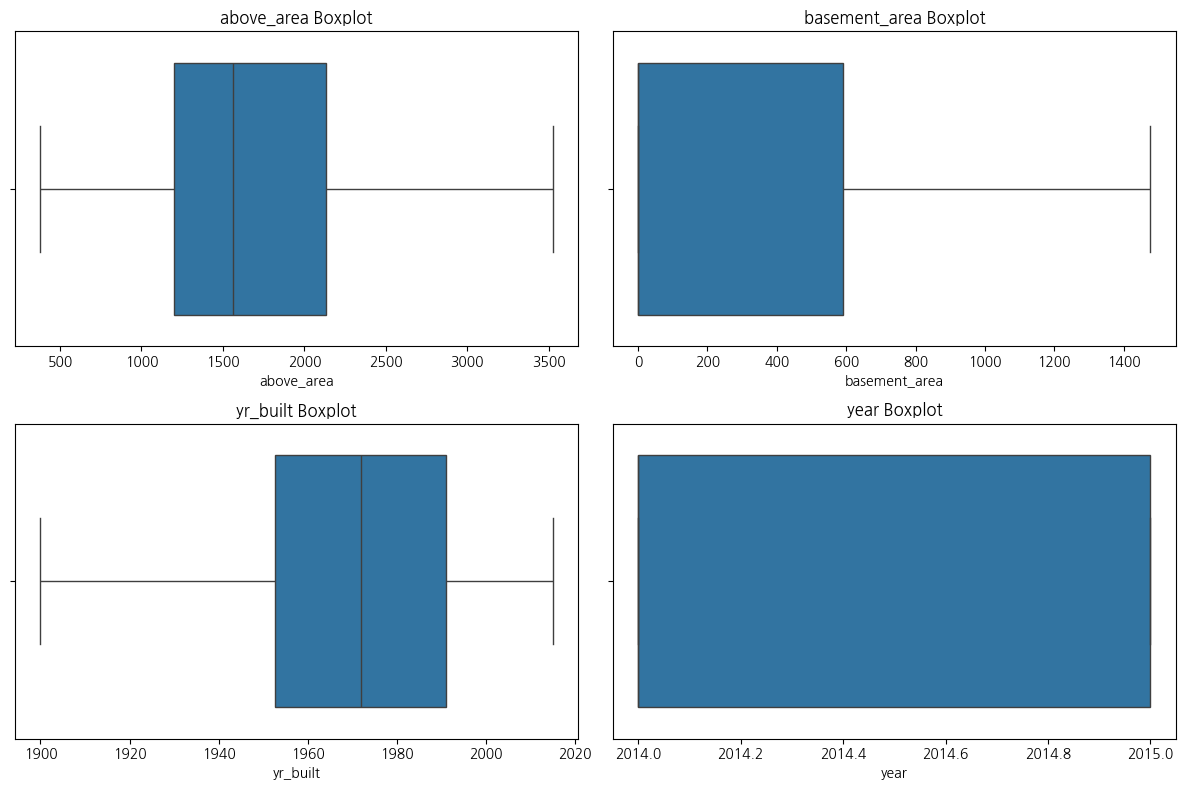

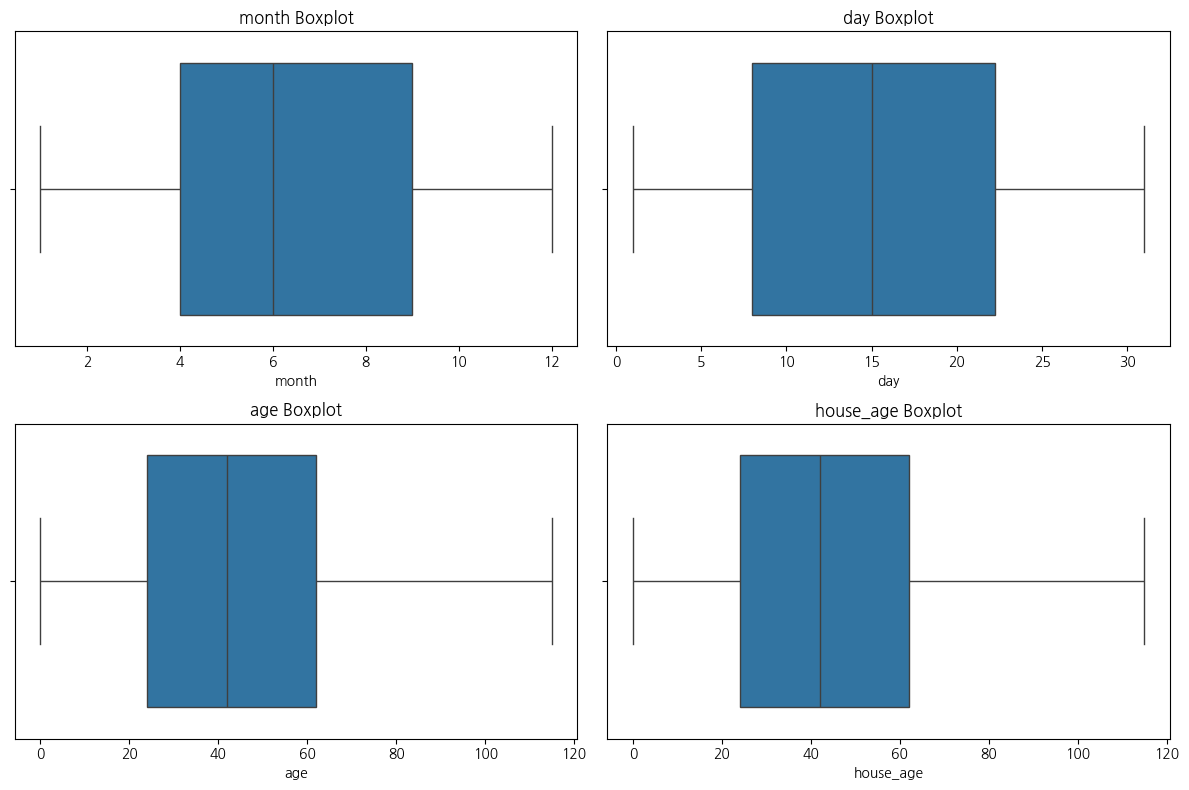

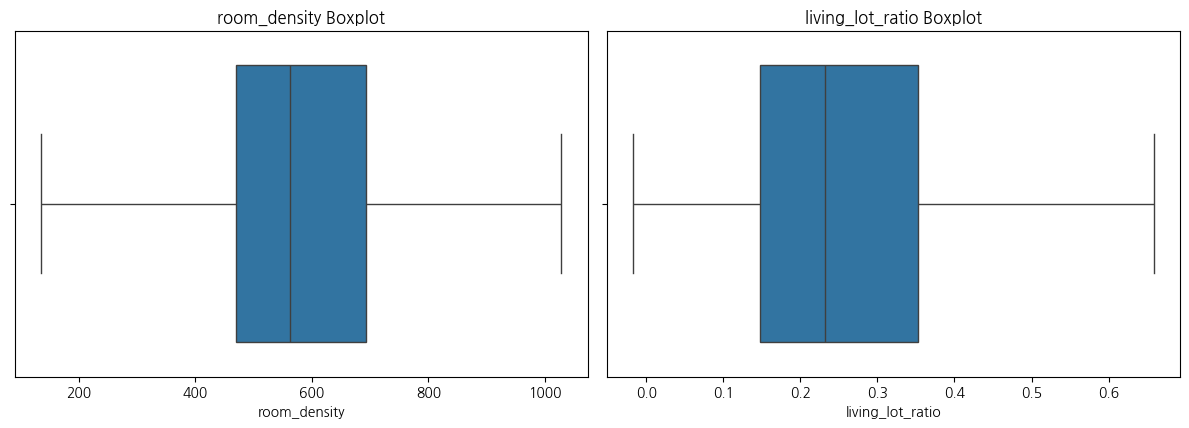

In [389]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 4개씩 묶어서 그리기
n_cols = len(num_cols)
group_size = 4  # 한 번에 그릴 그래프 개수

for i in range(0, n_cols, group_size):
    # 4개씩 슬라이싱
    sub_cols = num_cols[i:i + group_size]
    
    # 2x2 서브플롯 생성
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()  # 2D 배열(2,2)을 1D 배열(4,)로 펼쳐서 접근하기 쉽게 변경
    
    for j, col in enumerate(sub_cols):
        sns.boxplot(x=df_train[col], ax=axes[j])
        axes[j].set_title(f"{col} Boxplot")
        axes[j].set_xlabel(col)
        
    # 만약 남은 컬럼이 4개 미만인 경우, 빈 그래픽 공간(axis) 숨기기
    for k in range(len(sub_cols), group_size):
        fig.delaxes(axes[k])
        
    plt.tight_layout()
    plt.show()

# 분포 변환
 - 분포 변환 방법 : Log 변환
 - 변환 대상 : 연속형 설명변수

In [390]:
import pandas as pd
import numpy as np

# ==========================================
# 변수 분리
# ==========================================

# 전체 연속형 변수 추출 후 'price' 제외
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if "price" in num_cols:
    num_cols.remove("price")

# 범주형 변수 추출
cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.tolist()


# ==========================================
# Log Transformation 함수 정의
# ==========================================

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))


# ==========================================
# Train 및 Test 데이터 변환 적용
# ==========================================

# Train 연속형 변수 변환
train_log = df_train[num_cols].apply(signed_log1p)

# Test 연속형 변수 변환
test_log = df_test[num_cols].apply(signed_log1p)


# ==========================================
# 데이터 병합 (변환된 변수 + 원본 price + 범주형)
# ==========================================

# df_train
df_train = pd.concat(
    [
        train_log,              # Log 변환된 연속형 피처들
        df_train[["price"]],    # 원본 타겟 변수 (price)
        df_train[cat_cols]      # 범주형 변수들
    ],
    axis=1
)

# df_test
df_test = pd.concat(
    [
        test_log,               # Log 변환된 연속형 피처들
        df_test[["price"]],     # 원본 타겟 변수 (price)
        df_test[cat_cols]       # 범주형 변수들
    ],
    axis=1
)

### [Self-Practice]

- 실습 주제 : 분포 변환 효과 확인하기
- 실습 시나리오
   - 시나리오 1) Log 변환 직전의 Train 데이타에서 왜도값 확인하기
   - 시나리오 2) Log 변환 직후의 Train 데이타에서 왜도값 확인 후 변환전 왜도값과 비교하기

In [391]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if "price" in num_cols:
    num_cols.remove("price")

# ====================================================
# 시나리오 1) Log 변환 직전의 Train 데이터 왜도 확인
# ====================================================
skew_before = df_train[num_cols].skew()

# ====================================================
# 시나리오 2) Log 변환 적용 및 직후 왜도 확인 후 비교
# ====================================================
# Signed Log1p 변환 함수 적용 (0 또는 음수 대응)
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

# Train 데이터 연속형 변수 Log 변환
df_train_log = df_train[num_cols].apply(signed_log1p)

# Log 변환 후 왜도 산출
skew_after = df_train_log.skew()

# 변환 전/후 왜도 비교 데이터프레임 생성
skew_comparison = pd.DataFrame({
    "변환 전 왜도 (Before)": skew_before,
    "변환 후 왜도 (After)": skew_after,
    "왜도 변화량 (Shift)": skew_after - skew_before
}).sort_values(by="변환 전 왜도 (Before)", ascending=False)

print("=== [Log 변환 전/후 왜도(Skewness) 비교] ===")
print(skew_comparison.round(4))

=== [Log 변환 전/후 왜도(Skewness) 비교] ===
                  변환 전 왜도 (Before)  변환 후 왜도 (After)  왜도 변화량 (Shift)
year                        0.8306           0.8306         -0.0000
living_lot_ratio            0.6023           0.3929         -0.2095
floors                      0.4820           0.4188         -0.0632
basement_area               0.4640           0.4306         -0.0334
above_area                  0.1152           0.0039         -0.1113
living_area                -0.1307          -0.2628         -0.1321
bedrooms                   -0.2287          -0.4594         -0.2307
yr_built                   -0.5699          -0.5730         -0.0030
room_density               -0.5779          -0.8625         -0.2845
lot_area                   -0.6439          -0.9067         -0.2628
month                      -0.8244          -1.2073         -0.3829
day                        -0.9039          -1.3660         -0.4621
house_age                  -1.3331          -3.2777         -1.9446
age        

### 폰트 설정

In [392]:
# 한글 폰트 설정
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

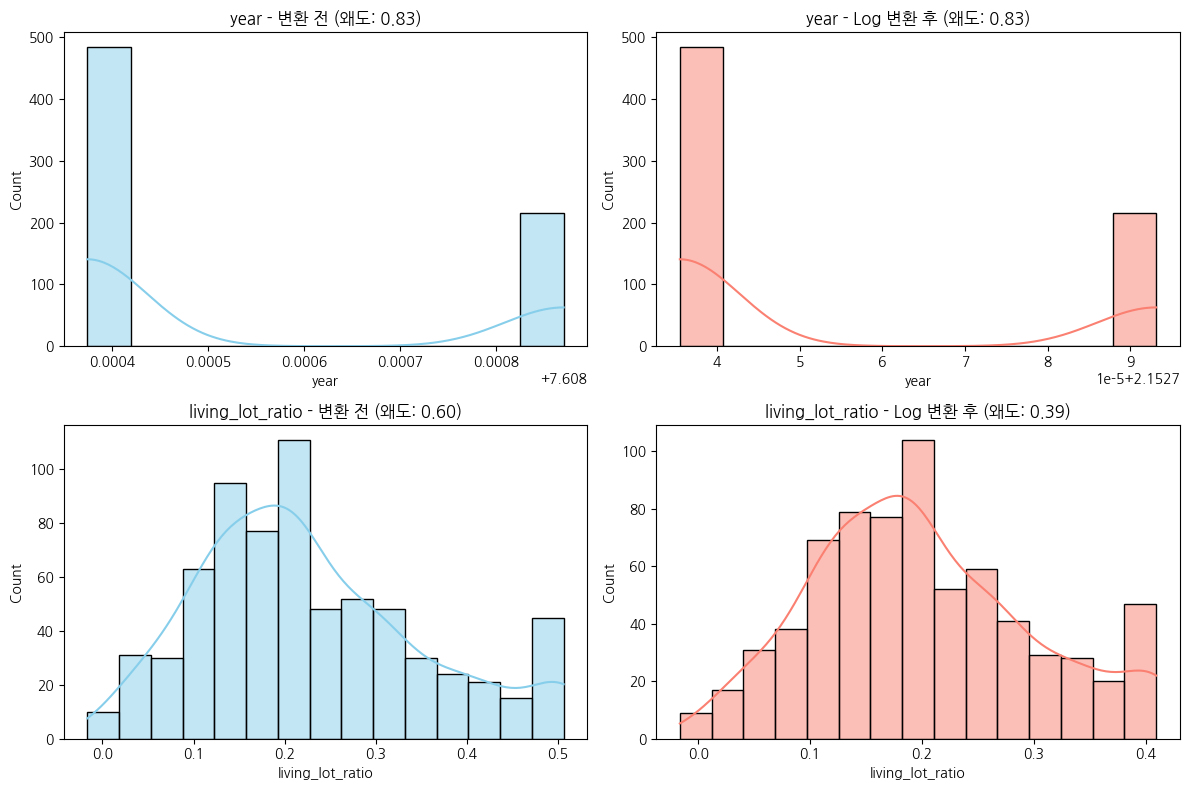

In [393]:
# 상위 왜도 변수 2개에 대해 변환 전/후 분포 그래프 출력
top_skew_cols = skew_comparison.index[:2].tolist()

fig, axes = plt.subplots(len(top_skew_cols), 2, figsize=(12, 4 * len(top_skew_cols)))

for i, col in enumerate(top_skew_cols):
    # 변환 전 분포
    sns.histplot(df_train[col], kde=True, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"{col} - 변환 전 (왜도: {skew_before[col]:.2f})")
    
    # 변환 후 분포
    sns.histplot(df_train_log[col], kde=True, ax=axes[i, 1], color="salmon")
    axes[i, 1].set_title(f"{col} - Log 변환 후 (왜도: {skew_after[col]:.2f})")

plt.tight_layout()
plt.show()

- 해당 변환은 선형 회귀 분석 모델에 앞서서 정규분포로 변환할 때 기존 값을 편향 영향을 낮추고자 진행함 (log 변환) - 정규성조건 충족
- living_lot_ratio: Log 변환 적용 추천 (왜도 감소 효과 확인) 
- year: Log 변환 비추천 (효과 없음, 범주화나 원본 연속형 유지 권장)

# 데이터 Scaling
 - Scaling 방법 : Min-Max 변환
- Scaling 대상 변수 : 연속형 설명변수

In [394]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# =========================
# 변수 분리
# =========================

# 연속형 변수
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

# price 제외
num_cols.remove("price")

# 범주형 변수
cat_cols = df_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# =========================
# Min-Max Scaling
# =========================

scaler = MinMaxScaler()

# Train 기준 학습
train_scaled = pd.DataFrame(
    scaler.fit_transform(df_train[num_cols]),
    columns=num_cols,
    index=df_train.index
)

# Test는 동일 기준 적용
test_scaled = pd.DataFrame(
    scaler.transform(df_test[num_cols]),
    columns=num_cols,
    index=df_test.index
)

# =========================
# 데이터 병합
# =========================

df_train = pd.concat(
    [
        train_scaled,            # 표준화된 연속형 변수
        df_train[["price"]],     # 원본 price
        df_train[cat_cols]       # 범주형 변수
    ],
    axis=1
)

df_test = pd.concat(
    [
        test_scaled,
        df_test[["price"]],
        df_test[cat_cols]
    ],
    axis=1
)

# 결과 확인
print(df_train.head())

     bedrooms  living_area  lot_area    floors  above_area  basement_area  \
541  0.190810     0.713286  0.679482  0.000000    0.438581       0.947924   
440  0.491887     0.619004  0.754619  0.000000    0.523399       0.821227   
482  0.491887     0.870745  0.734269  0.588891    0.915403       0.000000   
422  0.916231     0.689361  1.000000  0.000000    0.937909       1.000000   
778  0.725420     0.673409  0.783548  0.588891    0.707946       0.000000   

     yr_built  year     month       day       age  house_age  room_density  \
541  0.424555   0.0  0.910752  0.964495  0.884530   0.884530      0.991121   
440  0.546415   0.0  0.859833  0.830482  0.835220   0.835220      0.682192   
482  0.442017   0.0  0.910752  0.500000  0.878155   0.878155      0.972869   
422  0.641554   0.0  0.859833  0.675110  0.786284   0.786284      0.702324   
778  0.838780   1.0  0.216618  0.701839  0.630204   0.630204      0.603130   

     living_lot_ratio    price waterfront grade has_basement  
541  

### [Self-Practice]

- 실습 주제 : Scaling 방법 비교해 보기
- 실습 시나리오
   - 시나리오 1) Min-Max 변환 후 Train 데이타 기준으로 평균/ 표준편차/ 최소값/ 최대값 확인하기
   - 시나리오 2) Min-Max 대신 Z-Score 변환 후 Train 데이타 기준으로 평균/ 표준편차/ 최소값/ 최대값 확인하고, Min-Max 변환 결과와 비교하기

In [395]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 연속형 설명변수 추출 (목표변수 price 제외)
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
if "price" in num_cols:
    num_cols.remove("price")

# 시나리오 1) Min-Max 변환 후 Train 기준 통계량 확인
minmax_scaler = MinMaxScaler()
train_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_train[num_cols]),
    columns=num_cols,
    index=df_train.index
)

# Min-Max 통계량 요약
minmax_stats = pd.DataFrame({
    "Mean": train_minmax.mean(),
    "Std": train_minmax.std(),
    "Min": train_minmax.min(),
    "Max": train_minmax.max()
})

# 시나리오 2) Z-Score(Standard) 변환 후 Train 기준 통계량 확인
zscore_scaler = StandardScaler()
train_zscore = pd.DataFrame(
    zscore_scaler.fit_transform(df_train[num_cols]),
    columns=num_cols,
    index=df_train.index
)

# Z-Score 통계량 요약
zscore_stats = pd.DataFrame({
    "Mean": train_zscore.mean(),
    "Std": train_zscore.std(),
    "Min": train_zscore.min(),
    "Max": train_zscore.max()
})

# 두 변환 결과 상호 비교 출력
print("=== [1] Min-Max Scaling 결과 (Train 기준) ===")
print(minmax_stats.round(4))

print("\n=== [2] Z-Score (Standard) Scaling 결과 (Train 기준) ===")
print(zscore_stats.round(4))

=== [1] Min-Max Scaling 결과 (Train 기준) ===
                    Mean     Std  Min  Max
bedrooms          0.5573  0.2016  0.0  1.0
living_area       0.6808  0.1669  0.0  1.0
lot_area          0.7295  0.1768  0.0  1.0
floors            0.2558  0.2928  0.0  1.0
above_area        0.6450  0.1792  0.0  1.0
basement_area     0.3502  0.4350  0.0  1.0
yr_built          0.6061  0.2378  0.0  1.0
year              0.3086  0.4622  0.0  1.0
month             0.6514  0.2738  0.0  1.0
day               0.6883  0.2417  0.0  1.0
age               0.7569  0.1660  0.0  1.0
house_age         0.7569  0.1660  0.0  1.0
room_density      0.7089  0.1578  0.0  1.0
living_lot_ratio  0.4668  0.2379  0.0  1.0

=== [2] Z-Score (Standard) Scaling 결과 (Train 기준) ===
                  Mean     Std     Min     Max
bedrooms           0.0  1.0007 -2.7658  2.1971
living_area        0.0  1.0007 -4.0814  1.9133
lot_area          -0.0  1.0007 -4.1279  1.5307
floors             0.0  1.0007 -0.8744  2.5439
above_area         0.0  

- 스케일링을 통해 모델링 정확도를 높이기 위해
    - 스케일링이 필수인 모델: 선형 회귀(OLS, Ridge, Lasso), KNN, SVM, K-Means, PCA, 신경망(Neural Network)
    - 스케일링이 필요 없는 모델: 결정 트리(Decision Tree), 랜덤 포레스트(Random Forest), XGBoost, LightGBM 등 트리 기반 모델 (트리 분할 기준은 개별 피처 내 대소 관계만 보므로 스케일의 영향을 받지 않음)

# 상관분석
- 다중공선성 방지, 차원의 저주 문제 방지, 설명변수 축소 목적   
\* [참고] 차원의 저주: 변수의 개수가 너무 많은 경우 예측 성능이 떨어지는 현상    

- 상관이 너무 높으면 회귀 분석에서 (-)의 영향을 가짐 그런데 이 말이 이상해진다 -> 다중 공선성(변수 영량력이 제대로 해석되지 못함)
- 따라서 회귀식 때는 변수 하나가지고 Y를 예측함 


상관계수 산출

In [397]:
# 연속형 변수 추출
num_cols = df_train.select_dtypes(include=[np.number])

# 상관계수
corr_matrix = num_cols.corr()
print(corr_matrix)

                  bedrooms  living_area  lot_area    floors  above_area  \
bedrooms          1.000000     0.599062  0.211094  0.214437    0.520798   
living_area       0.599062     1.000000  0.298521  0.398273    0.838223   
lot_area          0.211094     0.298521  1.000000 -0.216530    0.307448   
floors            0.214437     0.398273 -0.216530  1.000000    0.600737   
above_area        0.520798     0.838223  0.307448  0.600737    1.000000   
basement_area     0.148655     0.276971 -0.030771 -0.305180   -0.222775   
yr_built          0.150750     0.272039  0.096413  0.389050    0.398514   
year             -0.038926    -0.069368  0.011962 -0.075573   -0.065534   
month             0.040955     0.019512 -0.023783  0.020704    0.024348   
day              -0.055325    -0.049854  0.005566  0.031538   -0.008912   
age              -0.113844    -0.256608  0.106201 -0.508635   -0.394073   
house_age        -0.113844    -0.256608  0.106201 -0.508635   -0.394073   
room_density     -0.06567

히트맵 시각화

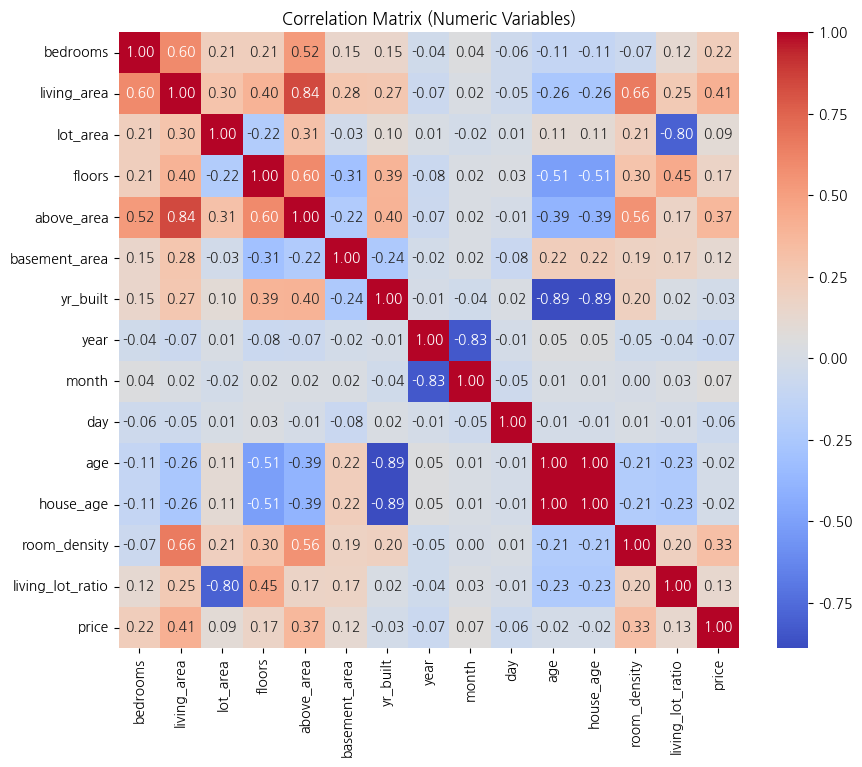

In [398]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numeric Variables)")
plt.show()

# 회귀 분석 준비

X, y 분리

In [ ]:
# train
Y_train = df_train['price']
X_train = df_train.drop(columns=['price'])

# test
Y_test = df_test['price']
X_test = df_test.drop(columns=['price'])

One-Hot Encoding
- k-1 개 dummy 변수 생성

In [ ]:
# 범주형 컬럼 선택
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

# dummy 변수화 + 연속형 자동 병합
# Train Set
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)   # True: k-1개 dummy, False: One-Hot Encoding

# Test Set
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# test를 train 컬럼 구조에 맞추기 (없는 컬럼은 0으로, train에 없는 test컬럼은 제거)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

 - X_train 변수 타입 확인

In [ ]:
X_train.dtypes

,0
bedrooms,float64
living_area,float64
lot_area,float64
floors,float64
above_area,float64
basement_area,float64
yr_built,float64
year,float64
month,float64
day,float64


- Bool Type -> Int Type 변환  *statsmodels 라이브러리 적용 위함

In [ ]:
# bool 컬럼 찾기
bool_cols = X_train.select_dtypes(include=['bool']).columns

# train, test 모두 변환
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

# 회귀 분석
 - statsmodels 라이브러리 사용, API 문서 : https://www.statsmodels.org/stable/index.html
 - statsmodels 라이브러리 : p-value, F 통계량 등 출력됨, 주로 통계적 추론 목적  
  \* [참고] sklearn.linear_model 라이브러리: p-value, F 통계량 등 출력안됨, 예측 목적  

학습 모델 생성
- statsmodels

In [ ]:
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error

# ==========================================
# Train 데이터로 회귀모델 생성
# ==========================================

# 절편(constant) 추가
X_train_const = sm.add_constant(X_train, has_constant="add")

# 회귀모델 생성
ols_model = sm.OLS(Y_train, X_train_const).fit()

# 회귀분석 결과
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     13.01
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           6.54e-43
Time:                        00:13:29   Log-Likelihood:                -9997.4
No. Observations:                 700   AIC:                         2.005e+04
Df Residuals:                     674   BIC:                         2.017e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 1.257e+06 

In [ ]:
# ==========================================
# Train 데이터 예측
# ==========================================

# 예측값 생성
train_pred = ols_model.predict(X_train_const)

# MAPE 계산
train_mape = mean_absolute_percentage_error(Y_train, train_pred) * 100

print(f"Train MAPE : {train_mape:.2f}%")

Train MAPE : 32.89%


In [ ]:
# ==========================================
# Test 데이터 예측
# ==========================================

# 절편 추가
X_test_const = sm.add_constant(X_test, has_constant="add")

# 예측값 생성
test_pred = ols_model.predict(X_test_const)

# MAPE 계산
test_mape = mean_absolute_percentage_error(Y_test, test_pred) * 100

print(f"Test MAPE : {test_mape:.2f}%")

Test MAPE : 30.95%


실제값 vs 예측값 비교
- 원래 Test 데이터에 예측값 병합하기

In [ ]:
df_test_raw["y_pred"] = test_pred
df_test_raw

,price,bedrooms,living_area,lot_area,floors,waterfront,grade,above_area,basement_area,yr_built,year,month,day,age,house_age,room_density,has_basement,living_lot_ratio,y_pred
521,610000,3.0,1180.0,3400,1.5,0.0,8등급,1180,0,1907.0,2014,10,22,107.0,107.0,393.333333,0,0.347059,7.931020e+05
737,345000,3.0,1250.0,7210,1.0,0.0,7등급,1250,0,1964.0,2015,1,22,51.0,51.0,416.666667,0,0.173370,3.037933e+05
740,650000,4.0,2950.0,5000,2.0,0.0,9등급,1980,970,1979.0,2015,1,24,36.0,36.0,737.500000,1,0.590000,7.388155e+05
660,345000,4.0,1550.0,7620,1.5,0.0,7등급,1550,0,1957.0,2014,12,10,57.0,57.0,387.500000,0,0.203412,4.694015e+05
411,400000,3.0,1190.0,1149,2.0,0.0,8등급,1050,140,2008.0,2014,9,11,6.0,6.0,396.666667,1,1.035683,3.623188e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
468,210000,2.0,830.0,6000,1.0,0.0,6등급,830,0,1940.0,2014,10,1,74.0,74.0,415.000000,0,0.138333,3.280125e+05
935,279000,6.0,2240.0,11180,2.0,0.0,7등급,2240,0,1955.0,2015,4,16,60.0,60.0,373.333333,0,0.200358,5.123764e+05
428,749000,4.0,1710.0,9627,1.0,0.0,9등급,1440,270,1976.0,2014,9,16,38.0,38.0,427.500000,1,0.177625,6.516224e+05
7,450000,2.0,1100.0,3000,1.5,0.0,7등급,1100,0,1912.0,2014,5,6,102.0,102.0,550.000000,0,0.366667,6.100368e+05


- 실제값 vs 예측값 시각화 비교

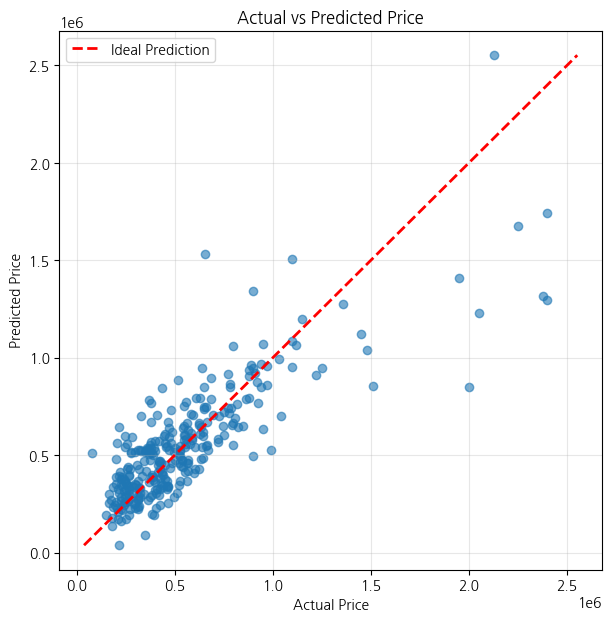

In [ ]:
import matplotlib.pyplot as plt

# 실제값과 예측값
actual = df_test_raw["price"]
pred = df_test_raw["y_pred"]

# 그래프 크기
plt.figure(figsize=(7, 7))

# 산점도
plt.scatter(actual, pred, alpha=0.6)

# y=x 기준선
min_val = min(actual.min(), pred.min())
max_val = max(actual.max(), pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Ideal Prediction"
)

# 그래프 설정
plt.title("Actual vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### [Self-Practice]

- 실습 주제 : 다중공선성 문제 해결과 변수 최적화 실험
- 실습 시나리오
   - 시나리오 1) 상관분석 결과에서 상관계수(|r|) ≥ 0.8 인 변수 중 하나를 제거하여 회귀모델을 생성한 후, 제거 전후의 Train, Test 데이터 MAPE 값을 비교함
  - 시나리오 2) 회귀분석 결과에서 변수 유의성 수준(P>|t|) ≥ 0.05 인 셜명변수를 제거하여 회귀모델을 생성한 후, 제거 전후의 후 Train 데이터 R-squared, Adj. R-squared, MAPE 값을 비교함
  - 시나리오 3) 파생변수 생성, 데이터 전처리(결측치 대체, 이상치 처리, 스케일링, 분포 변환), 상관분석 및 변수 유의성 검증을 통해 회귀모델을 반복적으로 개선하고, Test 데이터 기준 MAPE를 최소화하는 모델 파이프라인 생성하기

### 시나리오 1

In [399]:
Y_train.shape

(700,)

In [400]:
X_train_const.shape

(700, 18)

In [401]:
X_train_num = pd.get_dummies(X_train, drop_first=True).astype(float)
X_test_num = pd.get_dummies(X_test, drop_first=True).astype(float)

X_train_num, X_test_num = X_train_num.align(X_test_num, join='left', axis=1, fill_value=0)

y_tr = Y_train.astype(float)
y_te = Y_test.astype(float)

y_tr[:3], y_te[:3]

(541     355000.0
 440     469950.0
 482    1090000.0
 Name: price, dtype: float64,
 521    610000.0
 737    345000.0
 740    650000.0
 Name: price, dtype: float64)

In [402]:
def get_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [406]:
X_tr_sc1 = sm.add_constant(X_train_num)
X_te_sc1 = sm.add_constant(X_test_num)

model_sc1_before = sm.OLS(y_tr, X_tr_sc1).fit()

mape_tr_before = get_mape(y_tr, model_sc1_before.predict(X_tr_sc1))
mape_te_before = get_mape(y_te, model_sc1_before.predict(X_te_sc1))


In [407]:
corr_matrix = X_train_num.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [column for column in upper_tri.columns if any(upper_tri[column] >= 0.8)]

print(f"상관계수 (|r| >= 0.8) 탐지 변수: {high_corr_cols}")

상관계수 (|r| >= 0.8) 탐지 변수: ['above_area', 'month', 'age', 'house_age', 'has_basement_1']


In [410]:
# 해당 변수 제거 후 모델 재학습
X_tr_sc1_after = X_tr_sc1.drop(columns=high_corr_cols)
X_te_sc1_after = X_te_sc1.drop(columns=high_corr_cols)

model_sc1_after = sm.OLS(y_tr, X_tr_sc1_after).fit()

mape_tr_after = get_mape(y_tr, model_sc1_after.predict(X_tr_sc1_after))
mape_te_after = get_mape(y_te, model_sc1_after.predict(X_te_sc1_after))

sc1_df = pd.DataFrame({
    'Train MAPE (%)': [mape_tr_before, mape_tr_after],
    'Test MAPE (%)': [mape_te_before, mape_te_after]
}, index=['제거 전 (모든 변수)', f'제거 후 ({len(high_corr_cols)}개 변수 제거)'])

sc1_df

,Train MAPE (%),Test MAPE (%)
제거 전 (모든 변수),32.887364,30.953158
제거 후 (5개 변수 제거),32.906186,31.149993


- MAPE 낮아짐

### 시나리오 2

In [ ]:
p_vals = model_sc1_after.pvalues

# p-value >= 0.05 변수 추출 (절편 const 제외)
insignificant_vars = p_vals[(p_vals >= 0.05) & (p_vals.index != 'const')].index.tolist()
insignificant_vars

['bedrooms',
 'living_area',
 'lot_area',
 'floors',
 'basement_area',
 'year',
 'day',
 'room_density',
 'living_lot_ratio',
 'waterfront_Unknown',
 'grade_12등급',
 'grade_4등급',
 'grade_Unknown']

In [417]:
# 변수 제거 후 재학습
X_tr_sc2_after = X_tr_sc1_after.drop(columns=insignificant_vars)
X_te_sc2_after = X_te_sc1_after.drop(columns=insignificant_vars)

model_sc2_after = sm.OLS(y_tr, X_tr_sc2_after).fit()

In [418]:
sc2_df = pd.DataFrame({
    'Train R-squared': [model_sc1_after.rsquared, model_sc2_after.rsquared],
    'Train Adj. R-squared': [model_sc1_after.rsquared_adj, model_sc2_after.rsquared_adj],
    'Train MAPE (%)': [get_mape(y_tr, model_sc1_after.predict(X_tr_sc1_after)), get_mape(y_tr, model_sc2_after.predict(X_tr_sc2_after))],
    'Test MAPE (%)': [get_mape(y_te, model_sc1_after.predict(X_te_sc1_after)), get_mape(y_te, model_sc2_after.predict(X_te_sc2_after))]
}, index=['제거 전', '제거 후'])

sc2_df

,Train R-squared,Train Adj. R-squared,Train MAPE (%),Test MAPE (%)
제거 전,0.320242,0.299187,32.906186,31.149993
제거 후,0.282412,0.274104,35.805935,36.289772


### 시나리오 3

# Baseline 모델 평가
 - Naive Model  *가장 단순하고 직관적인 방법으로 만든 기준 모델

In [419]:
import numpy as np

# train 타겟 평균
y_mean = Y_train.mean()
print(f"Y Mean : {y_mean:.2f}")

# test 개수만큼 평균값 복제
y_pred_baseline = np.full(shape=len(Y_test), fill_value=y_mean)

# mape 계산
mape = mean_absolute_percentage_error(Y_test, y_pred_baseline) * 100
print(f"Baseline MAPE : {mape:.2f}%")

Y Mean : 533581.95
Baseline MAPE : 55.87%
